<a href="https://colab.research.google.com/github/AyushiB56/Neural-Network/blob/main/vanilla_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import torch
import torch.nn as nn
import os
import glob
import string
import unicodedata
import random
import io

In [125]:
all_letters= string.ascii_letters+ ' .,:;'
n_length = len(all_letters)

In [126]:
n_length

57

In [127]:
def unicode_to_ascii(s):
  return ''. join(c for c in unicodedata.normalize('NFD',s) if unicodedata.category(c)!= 'Mn' and c in all_letters)

In [128]:
def read_lines(line):
  lines= io.open(line,encoding='utf-8').read().strip().split('\n')
  return [unicode_to_ascii(line) for line in lines ]


In [129]:
def load_data():
  countries=[]
  categories= {}

  for filename in glob.glob('sample_data/data/*.txt'):
    country = os.path.splitext(os.path.basename(filename))[0]
    countries.append(country)
    lines= read_lines(filename)
    categories[country]= lines
  return countries,categories

In [130]:
def find_letter(letter):
  idx=all_letters.find(letter)
  return idx

In [131]:
def letter_to_ohe(letter):
  lttr_to_ohe= torch.zeros(n_length)
  lttr_to_ohe[0][find_letter(letter)]=1
  return lttr_to_ohe

In [132]:
def line_to_ohe(lines):
  lne_to_ohe= torch.zeros(len(lines), 1,n_length, dtype=torch.float)
  for i,letter in enumerate(lines):
    lne_to_ohe[i][0][find_letter(letter)]=1
  return lne_to_ohe

In [133]:
choice= random.randint(0, 9)

In [134]:
choice

2

In [135]:


def random_choice(countries,categories):
  def random_a(a):
    choice= random.randint(0, len(countries)-1)
    return a[choice]

  country = random_a(countries)
  category = random_a(categories[country])
  country_tensor= torch.tensor([countries.index(country)],dtype=torch.long)

  line_tensor= line_to_ohe(category)
  return category, country,country_tensor,line_tensor

In [160]:
class Rnn_model(nn.Module):
  def __init__(self, input_size, hidden_size,output_size):
    super(Rnn_model, self).__init__()
    self.hidden= hidden_size
    self.i2h= nn.Linear(input_size+hidden_size, hidden_size)
    self.i20= nn.Linear(input_size+hidden_size, output_size)
    self.softmax= nn.LogSoftmax(dim=1)

  def forward(self, input_tensor, hidden_tensor):
    combined= torch.cat((input_tensor,hidden_tensor),1)
    hidden= self.i2h(combined)
    output= self.i20(combined)
    output= self.softmax(output)
    return output, hidden
  def init_hidden(self):
    return torch.zeros(1, self.hidden)





In [161]:
def train(line_tensor):


  hidden_tensor= rnn.init_hidden()
  for i in range(0,len(line_tensor)-1):
    output, hidden= rnn(line_tensor[i], hidden_tensor)

  loss_fn= loss(output, country_tensor)
  optimizer.zero_grad()
  loss_fn.backward()
  optimizer.step()

  return loss_fn.item(),output





In [162]:
import numpy as np

In [199]:
loss_epoch=[]
result =[]
current_loss=0
countries, categories= load_data()
output_size=len(countries)
hidden_size=132
n_total=0
n_correct=0
rnn= Rnn_model(input_size=n_length,hidden_size=hidden_size,output_size=output_size)
loss= nn.NLLLoss()

optimizer= torch.optim.Adam(rnn.parameters(), lr=0.005)

for epoch in range(100000):

    category, country,country_tensor,line_tensor= random_choice(countries, categories)
    loss_fn,output= train(line_tensor)
    current_loss+=loss_fn

    if (epoch+1) % 1000 == 0:
      loss_epoch.append(current_loss/1000)
      current_loss=0
    if (epoch+1) % 5000 == 0:
        guess = category_output(output)
        guess_2= countries[guess]
        correct = "CORRECT" if guess_2 == country else f"WRONG ({country})"
        print(f"{epoch+1} {(epoch+1)/1000*100} {loss_fn:.4f} / {guess_2} {correct}")
        if guess_2 == country:
          n_correct+=1
        n_total+=1

accuracy= n_correct/n_total
print(accuracy)



5000 500.0 2.9493 / Dutch WRONG (Russian)
10000 1000.0 1.9330 / Dutch WRONG (German)
15000 1500.0 1.4234 / Russian CORRECT
20000 2000.0 1.8271 / Italian WRONG (Vietnamese)
25000 2500.0 2.8141 / Dutch WRONG (Russian)
30000 3000.0 1.6565 / Italian CORRECT
35000 3500.0 2.1754 / Greek WRONG (Arabic)
40000 4000.0 1.9645 / Japanese CORRECT
45000 4500.0 1.7618 / Japanese WRONG (Spanish)
50000 5000.0 2.0298 / Dutch WRONG (Japanese)
55000 5500.0 3.0835 / Dutch WRONG (Portuguese)
60000 6000.0 2.8905 / Dutch WRONG (Portuguese)
65000 6500.0 1.6388 / Korean WRONG (Japanese)
70000 7000.0 2.1482 / Polish WRONG (Russian)
75000 7500.0 2.0700 / Dutch WRONG (German)
80000 8000.0 2.6028 / Dutch WRONG (Russian)
85000 8500.0 2.7127 / Greek WRONG (Arabic)
90000 9000.0 2.1786 / Irish WRONG (Portuguese)
95000 9500.0 1.8544 / English WRONG (French)
100000 10000.0 2.2749 / Italian WRONG (Chinese)
0.15


In [182]:
import matplotlib.pyplot as plt

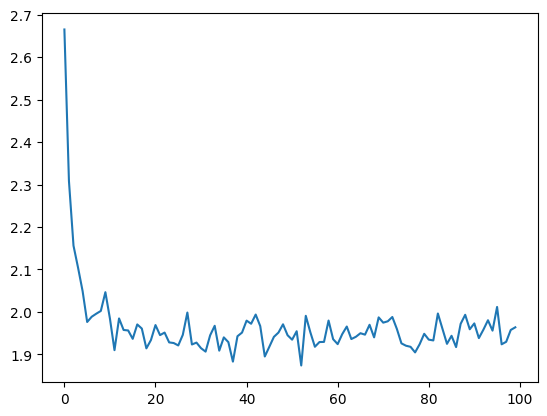

In [183]:
plt.figure()
plt.plot(loss_epoch)
plt.show()

In [200]:
def category_output(output):
  return torch.argmax(output)

In [201]:
def predict(input, ytrue):
  with torch.no_grad():
    line_tensor= line_to_ohe(input)
    hidden_tesnor= rnn.init_hidden()

    for i in range(line_tensor.size()[0]):
      output, hidden_tesnor= rnn(line_tensor[i], hidden_tesnor)

    ypred = countries[category_output(output)]

    if ypred == ytrue:
      return 1,ypred
    else:
      return 0,ypred




In [203]:
predict('Chao', 'Chinese')

(0, 'Greek')